In [246]:
import cobra
from cobra.io import (
    load_json_model,
    save_json_model,
    load_matlab_model,
    save_matlab_model,
    read_sbml_model,
    write_sbml_model,
)
from cobra.flux_analysis import flux_variability_analysis
import numpy as np
import pandas as pd

In [247]:
M_xanthus = read_sbml_model("../M_xanthus_model_V4.xml")
M_xanthus

Name,myxo_model
Memory address,75272b72d940
Number of metabolites,1224
Number of reactions,1339
Number of genes,1201
Number of groups,0
Objective expression,1.0*OF_BIOMASS - 1.0*OF_BIOMASS_reverse_80d2e
Compartments,"c, e"


In [248]:
hdca_e = cobra.Metabolite(
    "hdca_e", formula="C16H31O2", name="Palmitate [e]", compartment="e"
)
M_xanthus.add_metabolites(hdca_e)  # add M_xanthus.metabolites.Biomass_e
M_xanthus.add_boundary(
    M_xanthus.metabolites.get_by_id("hdca_e"), type="exchange"
)  # add the exchange reaction for Biomass_e

MXAN_7040 = cobra.Gene(id="MXAN_7040", name="MXAN_7040", functional=True)

FAreaction = cobra.Reaction("rxn08704_c")
FAreaction.name = "Hexadecanoate transport via facilitated irreversible diffusion (extracellular to periplasm)"  # Porin (Probably) so energy independant
FAreaction.subsystem = ""
FAreaction.lower_bound = -1000.0  # This is the default
FAreaction.upper_bound = 1000.0  # This is the default
hdca_e = M_xanthus.metabolites.hdca_e
hdca_c = M_xanthus.metabolites.hdca_c
FAreaction.add_metabolites(
    {hdca_e: -1, hdca_c: 1}
)  # add the metabolites to the reaction
FAreaction.gene_reaction_rule = "MXAN_7040"  # define which gene allow the reaction
M_xanthus.add_reactions([FAreaction])  # add the PR_Biomass reaction

M_xanthus.reactions.rxn08704_c.annotation = {
    "seed.reaction": "rxn08704",
    "bigg.reaction": ["FA160tp", "HDCAt", "HDCAtex", "HDCAtexi", "U209"],
    "metanetx.reaction": "MNXR99101",
}

M_xanthus.reactions.rxn08704_c

Ignoring reaction 'rxn08704_c' since it already exists.


Reaction identifier,rxn08704_c
Name,Hexadecanoate transport via facilitated irreversible diffusion (extracellular to periplasm)
Memory address,0x75272b9fa330
Stoichiometry,hdca_e <=> hdca_c Palmitate [e] <=> Palmitate [c]
GPR,MXAN_7040
Lower bound,-1000.0
Upper bound,1000.0


In [249]:
liste = []
for i in M_xanthus.exchanges._dict:
    liste.append(i)
    print("M_xanthus.reactions." + i + ".lower_bound = 0")
    # print(i + ": " + M_xanthus.reactions.get_by_id(i).name)

M_xanthus.reactions.EX_malt_e.lower_bound = 0
M_xanthus.reactions.EX_his_L_e.lower_bound = 0
M_xanthus.reactions.EX_cd2_e.lower_bound = 0
M_xanthus.reactions.EX_ferrich_e.lower_bound = 0
M_xanthus.reactions.EX_tttnt_e.lower_bound = 0
M_xanthus.reactions.EX_metox_e.lower_bound = 0
M_xanthus.reactions.EX_btn_e.lower_bound = 0
M_xanthus.reactions.EX_met_L_e.lower_bound = 0
M_xanthus.reactions.EX_mg2_e.lower_bound = 0
M_xanthus.reactions.EX_ac_e.lower_bound = 0
M_xanthus.reactions.EX_arsenb_e.lower_bound = 0
M_xanthus.reactions.EX_cbl1_e.lower_bound = 0
M_xanthus.reactions.EX_cgly_e.lower_bound = 0
M_xanthus.reactions.EX_fum_e.lower_bound = 0
M_xanthus.reactions.EX_h2s_e.lower_bound = 0
M_xanthus.reactions.EX_so4_e.lower_bound = 0
M_xanthus.reactions.EX_pydx_e.lower_bound = 0
M_xanthus.reactions.EX_spmd_e.lower_bound = 0
M_xanthus.reactions.EX_ppi_e.lower_bound = 0
M_xanthus.reactions.EX_mnl_e.lower_bound = 0
M_xanthus.reactions.EX_pro_L_e.lower_bound = 0
M_xanthus.reactions.EX_glyc3p_e.lo

In [250]:
df = M_xanthus.summary().uptake_flux
M_xanthus.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
Fe3_e,EX_Fe3_e,1.065,0,0.00%
alaala_e,EX_alaala_e,507.1,6,22.22%
ca2_e,EX_ca2_e,0.355,0,0.00%
cl_e,EX_cl_e,0.355,0,0.00%
co2_e,EX_co2_e,0.9311,1,0.01%
cobalt2_e,EX_cobalt2_e,0.355,0,0.00%
cu2_e,EX_cu2_e,0.355,0,0.00%
glu_L_e,EX_glu_L_e,198.6,5,7.25%
hdca_e,EX_hdca_e,137.5,16,16.06%
his_L_e,EX_his_L_e,16.97,6,0.74%


In [251]:
## NON ESSENTIAL METABOLITES
M_xanthus.reactions.EX_malt_e.lower_bound = 0
M_xanthus.reactions.EX_his_L_e.lower_bound = 0
M_xanthus.reactions.EX_cd2_e.lower_bound = 0
M_xanthus.reactions.EX_ferrich_e.lower_bound = 0
M_xanthus.reactions.EX_tttnt_e.lower_bound = 0
M_xanthus.reactions.EX_metox_e.lower_bound = 0
M_xanthus.reactions.EX_btn_e.lower_bound = 0
M_xanthus.reactions.EX_met_L_e.lower_bound = 0
M_xanthus.reactions.EX_ac_e.lower_bound = 0
M_xanthus.reactions.EX_arsenb_e.lower_bound = 0
M_xanthus.reactions.EX_cbl1_e.lower_bound = 0
M_xanthus.reactions.EX_cgly_e.lower_bound = 0
M_xanthus.reactions.EX_fum_e.lower_bound = 0
M_xanthus.reactions.EX_ppi_e.lower_bound = 0
M_xanthus.reactions.EX_mnl_e.lower_bound = 0
M_xanthus.reactions.EX_pro_L_e.lower_bound = 0
M_xanthus.reactions.EX_glyc3p_e.lower_bound = 0
M_xanthus.reactions.EX_orn_e.lower_bound = 0
M_xanthus.reactions.EX_salcn_e.lower_bound = 0
M_xanthus.reactions.EX_acgam_e.lower_bound = 0
M_xanthus.reactions.EX_pyr_e.lower_bound = 0
M_xanthus.reactions.EX_etoh_e.lower_bound = 0
M_xanthus.reactions.EX_but_e.lower_bound = 0
M_xanthus.reactions.EX_hom_L_e.lower_bound = 0
M_xanthus.reactions.EX_na1_e.lower_bound = 0
M_xanthus.reactions.EX_acald_e.lower_bound = 0
M_xanthus.reactions.EX_mobd_e.lower_bound = 0
M_xanthus.reactions.EX_metox_R_e.lower_bound = 0
M_xanthus.reactions.EX_arbt_e.lower_bound = 0
M_xanthus.reactions.EX_sucr_e.lower_bound = 0
M_xanthus.reactions.EX_galt_e.lower_bound = 0
M_xanthus.reactions.EX_glyb_e.lower_bound = 0
M_xanthus.reactions.EX_h2o_e.lower_bound = 0
M_xanthus.reactions.EX_so3_e.lower_bound = 0
M_xanthus.reactions.EX_h2_e.lower_bound = 0
M_xanthus.reactions.EX_lys_L_e.lower_bound = 0
M_xanthus.reactions.EX_n2o_e.lower_bound = 0
M_xanthus.reactions.EX_feenter_e.lower_bound = 0
M_xanthus.reactions.EX_fru_e.lower_bound = 0
M_xanthus.reactions.EX_gam_e.lower_bound = 0
M_xanthus.reactions.EX_gly_cys_L_e.lower_bound = 0
M_xanthus.reactions.EX_alaala_e.lower_bound = 0
M_xanthus.reactions.EX_co2_e.lower_bound = 0
M_xanthus.reactions.EX_h_e.lower_bound = 0
M_xanthus.reactions.EX_tre_e.lower_bound = 0
M_xanthus.reactions.EX_thr_L_e.lower_bound = 0
M_xanthus.reactions.EX_pheme_e.lower_bound = 0
M_xanthus.reactions.EX_glu_L_e.lower_bound = 0
M_xanthus.reactions.EX_malthx_e.lower_bound = 0
M_xanthus.reactions.EX_enter_e.lower_bound = 0
M_xanthus.reactions.EX_malttr_e.lower_bound = 0
M_xanthus.reactions.EX_arsni_e.lower_bound = 0
M_xanthus.reactions.EX_4hbz_e.lower_bound = 0
M_xanthus.reactions.EX_Butyro_betaine_e.lower_bound = 0
M_xanthus.reactions.EX_man_e.lower_bound = 0
M_xanthus.reactions.EX_chitob_e.lower_bound = 0
M_xanthus.reactions.EX_for_e.lower_bound = 0
M_xanthus.reactions.EX_mal_D_e.lower_bound = 0
M_xanthus.reactions.EX_adocbl_e.lower_bound = 0
M_xanthus.reactions.EX_meoh_e.lower_bound = 0
M_xanthus.reactions.EX_succ_e.lower_bound = 0
M_xanthus.reactions.EX_glc_D_e.lower_bound = 0
M_xanthus.reactions.EX_acac_e.lower_bound = 0
M_xanthus.reactions.EX_no_e.lower_bound = 0
M_xanthus.reactions.EX_lac_D_e.lower_bound = 0
M_xanthus.reactions.EX_tsul_e.lower_bound = 0

## ESSENTIAL METABOLITES
M_xanthus.reactions.EX_mg2_e.lower_bound = -1000
M_xanthus.reactions.EX_h2s_e.lower_bound = -1000
M_xanthus.reactions.EX_so4_e.lower_bound = -1000
M_xanthus.reactions.EX_pydx_e.lower_bound = -1000
M_xanthus.reactions.EX_spmd_e.lower_bound = -1000
M_xanthus.reactions.EX_pi_e.lower_bound = -1000
M_xanthus.reactions.EX_leu_L_e.lower_bound = -1000
M_xanthus.reactions.EX_k_e.lower_bound = -1000
M_xanthus.reactions.EX_cu2_e.lower_bound = -1000
M_xanthus.reactions.EX_ca2_e.lower_bound = -1000
M_xanthus.reactions.EX_zn2_e.lower_bound = -1000
M_xanthus.reactions.EX_cl_e.lower_bound = -1000
M_xanthus.reactions.EX_Fe3_e.lower_bound = -1000
M_xanthus.reactions.EX_mn2_e.lower_bound = -1000
M_xanthus.reactions.EX_nh4_e.lower_bound = -1000
M_xanthus.reactions.EX_ile_L_e.lower_bound = -1000
M_xanthus.reactions.EX_cobalt2_e.lower_bound = -1000
M_xanthus.reactions.EX_val_L_e.lower_bound = -1000
M_xanthus.reactions.EX_o2_e.lower_bound = -1000
M_xanthus.reactions.EX_hdca_e.lower_bound = -1000

In [252]:
FBA = M_xanthus.optimize()
FBA.objective_value

52.531708273294186

In [253]:
M_xanthus.metabolites.co2_e.summary()

Percent,Flux,Reaction,Definition
Percent,Flux,Reaction,Definition


In [254]:
M_xanthus.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
Fe3_e,EX_Fe3_e,0.3362,0,0.00%
ca2_e,EX_ca2_e,0.08405,0,0.00%
cl_e,EX_cl_e,0.08405,0,0.00%
cobalt2_e,EX_cobalt2_e,0.08405,0,0.00%
cu2_e,EX_cu2_e,0.08405,0,0.00%
h2s_e,EX_h2s_e,12.08,0,0.00%
hdca_e,EX_hdca_e,99.59,16,85.09%
ile_L_e,EX_ile_L_e,12.26,6,3.93%
k_e,EX_k_e,0.08405,0,0.00%
leu_L_e,EX_leu_L_e,19.03,6,6.10%


Test taking random value between a range

In [255]:
FVA = flux_variability_analysis(
    M_xanthus,
)

for i in liste:
    if FVA.loc[i][0] < 0:
        rdm = np.random.uniform(
            FVA.loc[i][0], FVA.loc[i][1]
        )  # get a random value between two point
        print(i + ": " + "\n" + "random   " + str(rdm) + "\n" + str(FVA.loc[i]))

EX_mg2_e: 
random   -0.08405286930461171
minimum   -0.084053
maximum   -0.084053
Name: EX_mg2_e, dtype: float64
EX_h2s_e: 
random   -12.081636828147454
minimum   -12.081637
maximum   -12.081637
Name: EX_h2s_e, dtype: float64
EX_so4_e: 
random   -0.08405286866914662
minimum   -0.084053
maximum   -0.084053
Name: EX_so4_e, dtype: float64
EX_pydx_e: 
random   -0.08405286978615573
minimum   -0.084053
maximum   -0.084053
Name: EX_pydx_e, dtype: float64
EX_spmd_e: 
random   -0.0840528694767441
minimum   -0.084053
maximum   -0.084053
Name: EX_spmd_e, dtype: float64
EX_pi_e: 
random   -34.72186375778066
minimum   -34.721864
maximum   -34.721864
Name: EX_pi_e, dtype: float64
EX_leu_L_e: 
random   -19.032956574734087
minimum   -19.032957
maximum   -19.032957
Name: EX_leu_L_e, dtype: float64
EX_k_e: 
random   -0.08405286930465804
minimum   -0.084053
maximum   -0.084053
Name: EX_k_e, dtype: float64
EX_cu2_e: 
random   -0.08405286930472036
minimum   -0.084053
maximum   -0.084053
Name: EX_cu2_e, dtyp

/tmp/ipykernel_14390/2419264253.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if FVA.loc[i][0] < 0:
/tmp/ipykernel_14390/2419264253.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  FVA.loc[i][0], FVA.loc[i][1]


In [256]:
np.random.uniform(
    FVA.loc["EX_hdca_e"][0], FVA.loc["EX_hdca_e"][1]
)  # get a random value between two point

/tmp/ipykernel_14390/922389116.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  FVA.loc["EX_hdca_e"][0], FVA.loc["EX_hdca_e"][1]


-103.54215278990871

Look at all FA available on the model

In [257]:
for i in M_xanthus.metabolites:
    if (
        "C16" in i.formula
        or "C14" in i.formula
        or "C18" in i.formula
        or "C12" in i.formula
        or "C20" in i.formula
    ):
        if (
            "N" not in i.formula
            and "S" not in i.formula
            and "P" not in i.formula
            and "O2" in i.formula
        ):
            print(i.name + "[" + i.id + "]: " + i.formula)

fa6 [c][fa6_c]: C16H31O2
hexadecenoate [c][hdcea_c]: C16H29O2
ddca [c][ddca_c]: C12H23O2
octadecenoate [c][ocdcea_c]: C18H33O2
Palmitate [c][hdca_c]: C16H31O2
Estrone [c][Estrone_c]: C18H22O2
ocdca [c][ocdca_c]: C18H35O2
Myristic acid [c][ttdca_c]: C14H27O2
tetradecenoate [c][ttdcea_c]: C14H25O2
fa1 [c][fa1_c]: C14H27O2
Palmitate [e][hdca_e]: C16H31O2


**Others FA**

ttdca: Myristic Acid

In [258]:
M_xanthus = read_sbml_model("../M_xanthus_model_V3_hdca.xml")
M_xanthus

Name,myxo_model
Memory address,75272ca38ce0
Number of metabolites,1224
Number of reactions,1339
Number of genes,1201
Number of groups,0
Objective expression,1.0*OF_BIOMASS - 1.0*OF_BIOMASS_reverse_80d2e
Compartments,"c, e"


In [259]:
ttdca_e = cobra.Metabolite(
    "ttdca_e", formula="C14H27O2", name="Myristic acid [e]", compartment="e"
)
M_xanthus.add_metabolites(ttdca_e)  # add M_xanthus.metabolites.Biomass_e
M_xanthus.add_boundary(
    M_xanthus.metabolites.get_by_id("ttdca_e"), type="exchange"
)  # add the exchange reaction for Biomass_e

MXAN_7040 = cobra.Gene(id="MXAN_7040", name="MXAN_7040", functional=True)

FAreaction = cobra.Reaction("rxn09331_c")
FAreaction.name = "Tetradecanoate transport via facilitated irreversible diffusion (extracellular to periplasm)"  # Porin (Probably) so energy independant
FAreaction.subsystem = ""
FAreaction.lower_bound = -1000.0  # This is the default
FAreaction.upper_bound = 1000.0  # This is the default
ttdca_e = M_xanthus.metabolites.ttdca_e
ttdca_c = M_xanthus.metabolites.ttdca_c
FAreaction.add_metabolites(
    {ttdca_e: -1, ttdca_c: 1}
)  # add the metabolites to the reaction
FAreaction.gene_reaction_rule = "MXAN_7040"  # define which gene allow the reaction
M_xanthus.add_reactions([FAreaction])  # add the PR_Biomass reaction

M_xanthus.reactions.rxn09331_c.annotation = {
    "seed.reaction": "rxn09331",
    "bigg.reaction": [" FA140tp", "TTDCAt", "TTDCAtex", "TTDCAtexi", "TTDCAtr", "U208"],
    "metanetx.reaction": "MNXR128297",
}

M_xanthus.reactions.rxn09331_c

Reaction identifier,rxn09331_c
Name,Tetradecanoate transport via facilitated irreversible diffusion (extracellular to periplasm)
Memory address,0x752721404800
Stoichiometry,ttdca_e <=> ttdca_c Myristic acid [e] <=> Myristic acid [c]
GPR,MXAN_7040
Lower bound,-1000.0
Upper bound,1000.0


In [260]:
## NON ESSENTIAL METABOLITES
M_xanthus.reactions.EX_malt_e.lower_bound = 0
M_xanthus.reactions.EX_his_L_e.lower_bound = 0
M_xanthus.reactions.EX_cd2_e.lower_bound = 0
M_xanthus.reactions.EX_ferrich_e.lower_bound = 0
M_xanthus.reactions.EX_tttnt_e.lower_bound = 0
M_xanthus.reactions.EX_metox_e.lower_bound = 0
M_xanthus.reactions.EX_btn_e.lower_bound = 0
M_xanthus.reactions.EX_met_L_e.lower_bound = 0
M_xanthus.reactions.EX_ac_e.lower_bound = 0
M_xanthus.reactions.EX_arsenb_e.lower_bound = 0
M_xanthus.reactions.EX_cbl1_e.lower_bound = 0
M_xanthus.reactions.EX_cgly_e.lower_bound = 0
M_xanthus.reactions.EX_fum_e.lower_bound = 0
M_xanthus.reactions.EX_ppi_e.lower_bound = 0
M_xanthus.reactions.EX_mnl_e.lower_bound = 0
M_xanthus.reactions.EX_pro_L_e.lower_bound = 0
M_xanthus.reactions.EX_glyc3p_e.lower_bound = 0
M_xanthus.reactions.EX_orn_e.lower_bound = 0
M_xanthus.reactions.EX_salcn_e.lower_bound = 0
M_xanthus.reactions.EX_acgam_e.lower_bound = 0
M_xanthus.reactions.EX_pyr_e.lower_bound = 0
M_xanthus.reactions.EX_etoh_e.lower_bound = 0
M_xanthus.reactions.EX_but_e.lower_bound = 0
M_xanthus.reactions.EX_hom_L_e.lower_bound = 0
M_xanthus.reactions.EX_na1_e.lower_bound = 0
M_xanthus.reactions.EX_acald_e.lower_bound = 0
M_xanthus.reactions.EX_mobd_e.lower_bound = 0
M_xanthus.reactions.EX_metox_R_e.lower_bound = 0
M_xanthus.reactions.EX_arbt_e.lower_bound = 0
M_xanthus.reactions.EX_sucr_e.lower_bound = 0
M_xanthus.reactions.EX_galt_e.lower_bound = 0
M_xanthus.reactions.EX_glyb_e.lower_bound = 0
M_xanthus.reactions.EX_h2o_e.lower_bound = 0
M_xanthus.reactions.EX_so3_e.lower_bound = 0
M_xanthus.reactions.EX_h2_e.lower_bound = 0
M_xanthus.reactions.EX_lys_L_e.lower_bound = 0
M_xanthus.reactions.EX_n2o_e.lower_bound = 0
M_xanthus.reactions.EX_feenter_e.lower_bound = 0
M_xanthus.reactions.EX_fru_e.lower_bound = 0
M_xanthus.reactions.EX_gam_e.lower_bound = 0
M_xanthus.reactions.EX_gly_cys_L_e.lower_bound = 0
M_xanthus.reactions.EX_alaala_e.lower_bound = 0
M_xanthus.reactions.EX_co2_e.lower_bound = 0
M_xanthus.reactions.EX_h_e.lower_bound = 0
M_xanthus.reactions.EX_tre_e.lower_bound = 0
M_xanthus.reactions.EX_thr_L_e.lower_bound = 0
M_xanthus.reactions.EX_pheme_e.lower_bound = 0
M_xanthus.reactions.EX_glu_L_e.lower_bound = 0
M_xanthus.reactions.EX_malthx_e.lower_bound = 0
M_xanthus.reactions.EX_enter_e.lower_bound = 0
M_xanthus.reactions.EX_malttr_e.lower_bound = 0
M_xanthus.reactions.EX_arsni_e.lower_bound = 0
M_xanthus.reactions.EX_4hbz_e.lower_bound = 0
M_xanthus.reactions.EX_Butyro_betaine_e.lower_bound = 0
M_xanthus.reactions.EX_man_e.lower_bound = 0
M_xanthus.reactions.EX_chitob_e.lower_bound = 0
M_xanthus.reactions.EX_for_e.lower_bound = 0
M_xanthus.reactions.EX_mal_D_e.lower_bound = 0
M_xanthus.reactions.EX_adocbl_e.lower_bound = 0
M_xanthus.reactions.EX_meoh_e.lower_bound = 0
M_xanthus.reactions.EX_succ_e.lower_bound = 0
M_xanthus.reactions.EX_glc_D_e.lower_bound = 0
M_xanthus.reactions.EX_acac_e.lower_bound = 0
M_xanthus.reactions.EX_no_e.lower_bound = 0
M_xanthus.reactions.EX_lac_D_e.lower_bound = 0
M_xanthus.reactions.EX_tsul_e.lower_bound = 0

## ESSENTIAL METABOLITES
M_xanthus.reactions.EX_mg2_e.lower_bound = -1000
M_xanthus.reactions.EX_h2s_e.lower_bound = -1000
M_xanthus.reactions.EX_so4_e.lower_bound = -1000
M_xanthus.reactions.EX_pydx_e.lower_bound = -1000
M_xanthus.reactions.EX_spmd_e.lower_bound = -1000
M_xanthus.reactions.EX_pi_e.lower_bound = -1000
M_xanthus.reactions.EX_leu_L_e.lower_bound = -1000
M_xanthus.reactions.EX_k_e.lower_bound = -1000
M_xanthus.reactions.EX_cu2_e.lower_bound = -1000
M_xanthus.reactions.EX_ca2_e.lower_bound = -1000
M_xanthus.reactions.EX_zn2_e.lower_bound = -1000
M_xanthus.reactions.EX_cl_e.lower_bound = -1000
M_xanthus.reactions.EX_Fe3_e.lower_bound = -1000
M_xanthus.reactions.EX_mn2_e.lower_bound = -1000
M_xanthus.reactions.EX_nh4_e.lower_bound = -1000
M_xanthus.reactions.EX_ile_L_e.lower_bound = -1000
M_xanthus.reactions.EX_cobalt2_e.lower_bound = -1000
M_xanthus.reactions.EX_val_L_e.lower_bound = -1000
M_xanthus.reactions.EX_o2_e.lower_bound = -1000
M_xanthus.reactions.EX_ttdca_e.lower_bound = -1000
# M_xanthus.reactions.EX_hdca_e.lower_bound = -1000

In [261]:
FBA = M_xanthus.optimize()
FBA.objective_value

52.5317082732141

In [262]:
M_xanthus.genes.MXAN_7040

Gene identifier,MXAN_7040
Name,G_MXAN_7040
Memory address,0x75272be06270
Functional,True
In 2 reaction(s),"rxn09331_c, rxn08704_c"


In [263]:
M_xanthus.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
Fe3_e,EX_Fe3_e,0.3362,0,0.00%
ca2_e,EX_ca2_e,0.08405,0,0.00%
cl_e,EX_cl_e,0.08405,0,0.00%
cobalt2_e,EX_cobalt2_e,0.08405,0,0.00%
cu2_e,EX_cu2_e,0.08405,0,0.00%
h2s_e,EX_h2s_e,12.08,0,0.00%
hdca_e,EX_hdca_e,99.59,16,85.09%
ile_L_e,EX_ile_L_e,12.26,6,3.93%
k_e,EX_k_e,0.08405,0,0.00%
leu_L_e,EX_leu_L_e,19.03,6,6.10%


fa1: Fatty Acid C14:0

fa6: Fatty Acid C16:0

In [264]:
M_xanthus.metabolites.ttdca_c.reactions

frozenset({<Reaction rxn05736_c at 0x75272d98d3d0>,
           <Reaction rxn08441_c at 0x75272ce1fc20>,
           <Reaction rxn08797_c at 0x75272cc2fec0>,
           <Reaction rxn08804_c at 0x75272ceeb0e0>,
           <Reaction rxn08811_c at 0x75272cfc7ad0>,
           <Reaction rxn08818_c at 0x75272c2718e0>,
           <Reaction rxn08839_c at 0x75272c1c42f0>,
           <Reaction rxn08846_c at 0x75272ce3cce0>,
           <Reaction rxn09331_c at 0x752721404800>})

In [265]:
M_xanthus = read_sbml_model("../M_xanthus_model_V3_hdca.xml")
M_xanthus

Name,myxo_model
Memory address,752720b4e420
Number of metabolites,1224
Number of reactions,1339
Number of genes,1201
Number of groups,0
Objective expression,1.0*OF_BIOMASS - 1.0*OF_BIOMASS_reverse_80d2e
Compartments,"c, e"


In [266]:
M_xanthus.metabolites.fa6_c

Metabolite identifier,fa6_c
Name,fa6 [c]
Memory address,0x752720a04bc0
Formula,C16H31O2
Compartment,c
In 2 reaction(s),"rxn05280_c, rxn05250_c"


In [267]:
fa6_e = cobra.Metabolite(
    "fa6_e", formula="C16H31O2", name="Fatty Acid C16:0 [e]", compartment="e"
)
M_xanthus.add_metabolites(fa6_e)  # add M_xanthus.metabolites.Biomass_e
M_xanthus.add_boundary(
    M_xanthus.metabolites.get_by_id("fa6_e"), type="exchange"
)  # add the exchange reaction for Biomass_e

MXAN_7040 = cobra.Gene(id="MXAN_7040", name="MXAN_7040", functional=True)

FAreaction = cobra.Reaction("rxn09331_c")
FAreaction.name = "Tetradecanoate transport via facilitated irreversible diffusion (extracellular to periplasm)"  # Porin (Probably) so energy independant
FAreaction.subsystem = ""
FAreaction.lower_bound = -1000.0  # This is the default
FAreaction.upper_bound = 1000.0  # This is the default
fa6_e = M_xanthus.metabolites.fa6_e
fa6_c = M_xanthus.metabolites.fa6_c
FAreaction.add_metabolites({fa6_e: -1, fa6_c: 1})  # add the metabolites to the reaction
FAreaction.gene_reaction_rule = "MXAN_7040"  # define which gene allow the reaction
M_xanthus.add_reactions([FAreaction])  # add the PR_Biomass reaction

M_xanthus.reactions.rxn09331_c.annotation = {
    "seed.reaction": "rxn09331",
    "bigg.reaction": [" FA140tp", "TTDCAt", "TTDCAtex", "TTDCAtexi", "TTDCAtr", "U208"],
    "metanetx.reaction": "MNXR128297",
}

M_xanthus.reactions.rxn09331_c

Reaction identifier,rxn09331_c
Name,Tetradecanoate transport via facilitated irreversible diffusion (extracellular to periplasm)
Memory address,0x75272daeb200
Stoichiometry,fa6_e <=> fa6_c Fatty Acid C16:0 [e] <=> fa6 [c]
GPR,MXAN_7040
Lower bound,-1000.0
Upper bound,1000.0


In [268]:
## NON ESSENTIAL METABOLITES
M_xanthus.reactions.EX_malt_e.lower_bound = 0
M_xanthus.reactions.EX_his_L_e.lower_bound = 0
M_xanthus.reactions.EX_cd2_e.lower_bound = 0
M_xanthus.reactions.EX_ferrich_e.lower_bound = 0
M_xanthus.reactions.EX_tttnt_e.lower_bound = 0
M_xanthus.reactions.EX_metox_e.lower_bound = 0
M_xanthus.reactions.EX_btn_e.lower_bound = 0
M_xanthus.reactions.EX_met_L_e.lower_bound = 0
M_xanthus.reactions.EX_ac_e.lower_bound = 0
M_xanthus.reactions.EX_arsenb_e.lower_bound = 0
M_xanthus.reactions.EX_cbl1_e.lower_bound = 0
M_xanthus.reactions.EX_cgly_e.lower_bound = 0
M_xanthus.reactions.EX_fum_e.lower_bound = 0
M_xanthus.reactions.EX_ppi_e.lower_bound = 0
M_xanthus.reactions.EX_mnl_e.lower_bound = 0
M_xanthus.reactions.EX_pro_L_e.lower_bound = 0
M_xanthus.reactions.EX_glyc3p_e.lower_bound = 0
M_xanthus.reactions.EX_orn_e.lower_bound = 0
M_xanthus.reactions.EX_salcn_e.lower_bound = 0
M_xanthus.reactions.EX_acgam_e.lower_bound = 0
M_xanthus.reactions.EX_pyr_e.lower_bound = 0
M_xanthus.reactions.EX_etoh_e.lower_bound = 0
M_xanthus.reactions.EX_but_e.lower_bound = 0
M_xanthus.reactions.EX_hom_L_e.lower_bound = 0
M_xanthus.reactions.EX_na1_e.lower_bound = 0
M_xanthus.reactions.EX_acald_e.lower_bound = 0
M_xanthus.reactions.EX_mobd_e.lower_bound = 0
M_xanthus.reactions.EX_metox_R_e.lower_bound = 0
M_xanthus.reactions.EX_arbt_e.lower_bound = 0
M_xanthus.reactions.EX_sucr_e.lower_bound = 0
M_xanthus.reactions.EX_galt_e.lower_bound = 0
M_xanthus.reactions.EX_glyb_e.lower_bound = 0
M_xanthus.reactions.EX_h2o_e.lower_bound = 0
M_xanthus.reactions.EX_so3_e.lower_bound = 0
M_xanthus.reactions.EX_h2_e.lower_bound = 0
M_xanthus.reactions.EX_lys_L_e.lower_bound = 0
M_xanthus.reactions.EX_n2o_e.lower_bound = 0
M_xanthus.reactions.EX_feenter_e.lower_bound = 0
M_xanthus.reactions.EX_fru_e.lower_bound = 0
M_xanthus.reactions.EX_gam_e.lower_bound = 0
M_xanthus.reactions.EX_gly_cys_L_e.lower_bound = 0
M_xanthus.reactions.EX_alaala_e.lower_bound = 0
M_xanthus.reactions.EX_co2_e.lower_bound = 0
M_xanthus.reactions.EX_h_e.lower_bound = 0
M_xanthus.reactions.EX_tre_e.lower_bound = 0
M_xanthus.reactions.EX_thr_L_e.lower_bound = 0
M_xanthus.reactions.EX_pheme_e.lower_bound = 0
M_xanthus.reactions.EX_glu_L_e.lower_bound = 0
M_xanthus.reactions.EX_malthx_e.lower_bound = 0
M_xanthus.reactions.EX_enter_e.lower_bound = 0
M_xanthus.reactions.EX_malttr_e.lower_bound = 0
M_xanthus.reactions.EX_arsni_e.lower_bound = 0
M_xanthus.reactions.EX_4hbz_e.lower_bound = 0
M_xanthus.reactions.EX_Butyro_betaine_e.lower_bound = 0
M_xanthus.reactions.EX_man_e.lower_bound = 0
M_xanthus.reactions.EX_chitob_e.lower_bound = 0
M_xanthus.reactions.EX_for_e.lower_bound = 0
M_xanthus.reactions.EX_mal_D_e.lower_bound = 0
M_xanthus.reactions.EX_adocbl_e.lower_bound = 0
M_xanthus.reactions.EX_meoh_e.lower_bound = 0
M_xanthus.reactions.EX_succ_e.lower_bound = 0
M_xanthus.reactions.EX_glc_D_e.lower_bound = 0
M_xanthus.reactions.EX_acac_e.lower_bound = 0
M_xanthus.reactions.EX_no_e.lower_bound = 0
M_xanthus.reactions.EX_lac_D_e.lower_bound = 0
M_xanthus.reactions.EX_tsul_e.lower_bound = 0

#M_xanthus.reactions.EX_fa1_e.lower_bound = 0
M_xanthus.reactions.EX_fa6_e.lower_bound = 0

## ESSENTIAL METABOLITES
M_xanthus.reactions.EX_mg2_e.lower_bound = -1000
M_xanthus.reactions.EX_h2s_e.lower_bound = -1000
M_xanthus.reactions.EX_so4_e.lower_bound = -1000
M_xanthus.reactions.EX_pydx_e.lower_bound = -1000
M_xanthus.reactions.EX_spmd_e.lower_bound = -1000
M_xanthus.reactions.EX_pi_e.lower_bound = -1000
M_xanthus.reactions.EX_leu_L_e.lower_bound = -1000
M_xanthus.reactions.EX_k_e.lower_bound = -1000
M_xanthus.reactions.EX_cu2_e.lower_bound = -1000
M_xanthus.reactions.EX_ca2_e.lower_bound = -1000
M_xanthus.reactions.EX_zn2_e.lower_bound = -1000
M_xanthus.reactions.EX_cl_e.lower_bound = -1000
M_xanthus.reactions.EX_Fe3_e.lower_bound = -1000
M_xanthus.reactions.EX_mn2_e.lower_bound = -1000
M_xanthus.reactions.EX_nh4_e.lower_bound = -1000
M_xanthus.reactions.EX_ile_L_e.lower_bound = -1000
M_xanthus.reactions.EX_cobalt2_e.lower_bound = -1000
M_xanthus.reactions.EX_val_L_e.lower_bound = -1000
M_xanthus.reactions.EX_o2_e.lower_bound = -1000
M_xanthus.reactions.EX_hdca_e.lower_bound = -1000

In [269]:
FBA = M_xanthus.optimize()
FBA.objective_value

52.531708273217184

In [270]:
df2 = M_xanthus.summary().uptake_flux
M_xanthus.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
Fe3_e,EX_Fe3_e,0.3362,0,0.00%
ca2_e,EX_ca2_e,0.08405,0,0.00%
cl_e,EX_cl_e,0.08405,0,0.00%
cobalt2_e,EX_cobalt2_e,0.08405,0,0.00%
cu2_e,EX_cu2_e,0.08405,0,0.00%
h2s_e,EX_h2s_e,12.08,0,0.00%
hdca_e,EX_hdca_e,99.59,16,85.09%
ile_L_e,EX_ile_L_e,12.26,6,3.93%
k_e,EX_k_e,0.08405,0,0.00%
leu_L_e,EX_leu_L_e,19.03,6,6.10%


In [271]:
df

,flux,reaction,metabolite
EX_Fe3_e,1.065057,EX_Fe3_e,Fe3_e
EX_alaala_e,507.117795,EX_alaala_e,alaala_e
EX_ca2_e,0.355019,EX_ca2_e,ca2_e
EX_cl_e,0.355019,EX_cl_e,cl_e
EX_co2_e,0.931140,EX_co2_e,co2_e
EX_cobalt2_e,0.355019,EX_cobalt2_e,cobalt2_e
EX_cu2_e,0.355019,EX_cu2_e,cu2_e
EX_glu_L_e,198.590783,EX_glu_L_e,glu_L_e
EX_hdca_e,137.482599,EX_hdca_e,hdca_e
EX_his_L_e,16.974534,EX_his_L_e,his_L_e


In [272]:
df2

,flux,reaction,metabolite
EX_Fe3_e,0.336211,EX_Fe3_e,Fe3_e
EX_ca2_e,0.084053,EX_ca2_e,ca2_e
EX_cl_e,0.084053,EX_cl_e,cl_e
EX_cobalt2_e,0.084053,EX_cobalt2_e,cobalt2_e
EX_cu2_e,0.084053,EX_cu2_e,cu2_e
EX_h2s_e,12.081637,EX_h2s_e,h2s_e
EX_hdca_e,99.594053,EX_hdca_e,hdca_e
EX_ile_L_e,12.259662,EX_ile_L_e,ile_L_e
EX_k_e,0.084053,EX_k_e,k_e
EX_leu_L_e,19.032957,EX_leu_L_e,leu_L_e


In [273]:
df_row = [] 
for index, row in df.iterrows():
    df_row.append(index)

df_row2 = [] 
for index, row in df2.iterrows():
    df_row2.append(index)

In [274]:
df_row2

['EX_Fe3_e',
 'EX_ca2_e',
 'EX_cl_e',
 'EX_cobalt2_e',
 'EX_cu2_e',
 'EX_h2s_e',
 'EX_hdca_e',
 'EX_ile_L_e',
 'EX_k_e',
 'EX_leu_L_e',
 'EX_mg2_e',
 'EX_mn2_e',
 'EX_nh4_e',
 'EX_o2_e',
 'EX_pi_e',
 'EX_pydx_e',
 'EX_so4_e',
 'EX_spmd_e',
 'EX_val_L_e',
 'EX_zn2_e']

In [275]:
for i in df_row:
    if i not in df_row2:
        new_row = pd.DataFrame({"flux": [0], "reaction": [i], "metabolite": [M_xanthus.reactions.get_by_id(i).reaction.split()[0]]})
        # new_row.set_index("", inplace=True)
        print(new_row)
        df2 = pd.concat([df2, new_row], ignore_index=True)

   flux     reaction metabolite
0     0  EX_alaala_e   alaala_e
   flux  reaction metabolite
0     0  EX_co2_e      co2_e
   flux    reaction metabolite
0     0  EX_glu_L_e    glu_L_e
   flux    reaction metabolite
0     0  EX_his_L_e    his_L_e
   flux    reaction metabolite
0     0  EX_lys_L_e    lys_L_e
   flux   reaction metabolite
0     0  EX_malt_e     malt_e
   flux    reaction metabolite
0     0  EX_met_L_e    met_L_e
   flux    reaction metabolite
0     0  EX_pheme_e    pheme_e
   flux   reaction metabolite
0     0  EX_tsul_e     tsul_e


In [276]:
rename_col = {"flux": "flux_FA"}

In [277]:
df2.set_index("reaction", drop=False, inplace=True)
df2

,flux,reaction,metabolite
reaction,,,
EX_Fe3_e,0.336211,EX_Fe3_e,Fe3_e
EX_ca2_e,0.084053,EX_ca2_e,ca2_e
EX_cl_e,0.084053,EX_cl_e,cl_e
EX_cobalt2_e,0.084053,EX_cobalt2_e,cobalt2_e
EX_cu2_e,0.084053,EX_cu2_e,cu2_e
EX_h2s_e,12.081637,EX_h2s_e,h2s_e
EX_hdca_e,99.594053,EX_hdca_e,hdca_e
EX_ile_L_e,12.259662,EX_ile_L_e,ile_L_e
EX_k_e,0.084053,EX_k_e,k_e


In [278]:
df2["flux_FA"] = df2["flux"]
df2 = df2.drop("flux", axis=1)
df2

,reaction,metabolite,flux_FA
reaction,,,
EX_Fe3_e,EX_Fe3_e,Fe3_e,0.336211
EX_ca2_e,EX_ca2_e,ca2_e,0.084053
EX_cl_e,EX_cl_e,cl_e,0.084053
EX_cobalt2_e,EX_cobalt2_e,cobalt2_e,0.084053
EX_cu2_e,EX_cu2_e,cu2_e,0.084053
EX_h2s_e,EX_h2s_e,h2s_e,12.081637
EX_hdca_e,EX_hdca_e,hdca_e,99.594053
EX_ile_L_e,EX_ile_L_e,ile_L_e,12.259662
EX_k_e,EX_k_e,k_e,0.084053


In [279]:
df2 = pd.concat([df2, df], axis=1,ignore_index=False)

In [280]:
df2 = df2.iloc[:, :-2]
df2

,reaction,metabolite,flux_FA,flux
EX_Fe3_e,EX_Fe3_e,Fe3_e,0.336211,1.065057
EX_ca2_e,EX_ca2_e,ca2_e,0.084053,0.355019
EX_cl_e,EX_cl_e,cl_e,0.084053,0.355019
EX_cobalt2_e,EX_cobalt2_e,cobalt2_e,0.084053,0.355019
EX_cu2_e,EX_cu2_e,cu2_e,0.084053,0.355019
EX_h2s_e,EX_h2s_e,h2s_e,12.081637,NaN
EX_hdca_e,EX_hdca_e,hdca_e,99.594053,137.482599
EX_ile_L_e,EX_ile_L_e,ile_L_e,12.259662,51.781866
EX_k_e,EX_k_e,k_e,0.084053,0.355019
EX_leu_L_e,EX_leu_L_e,leu_L_e,19.032957,80.390631


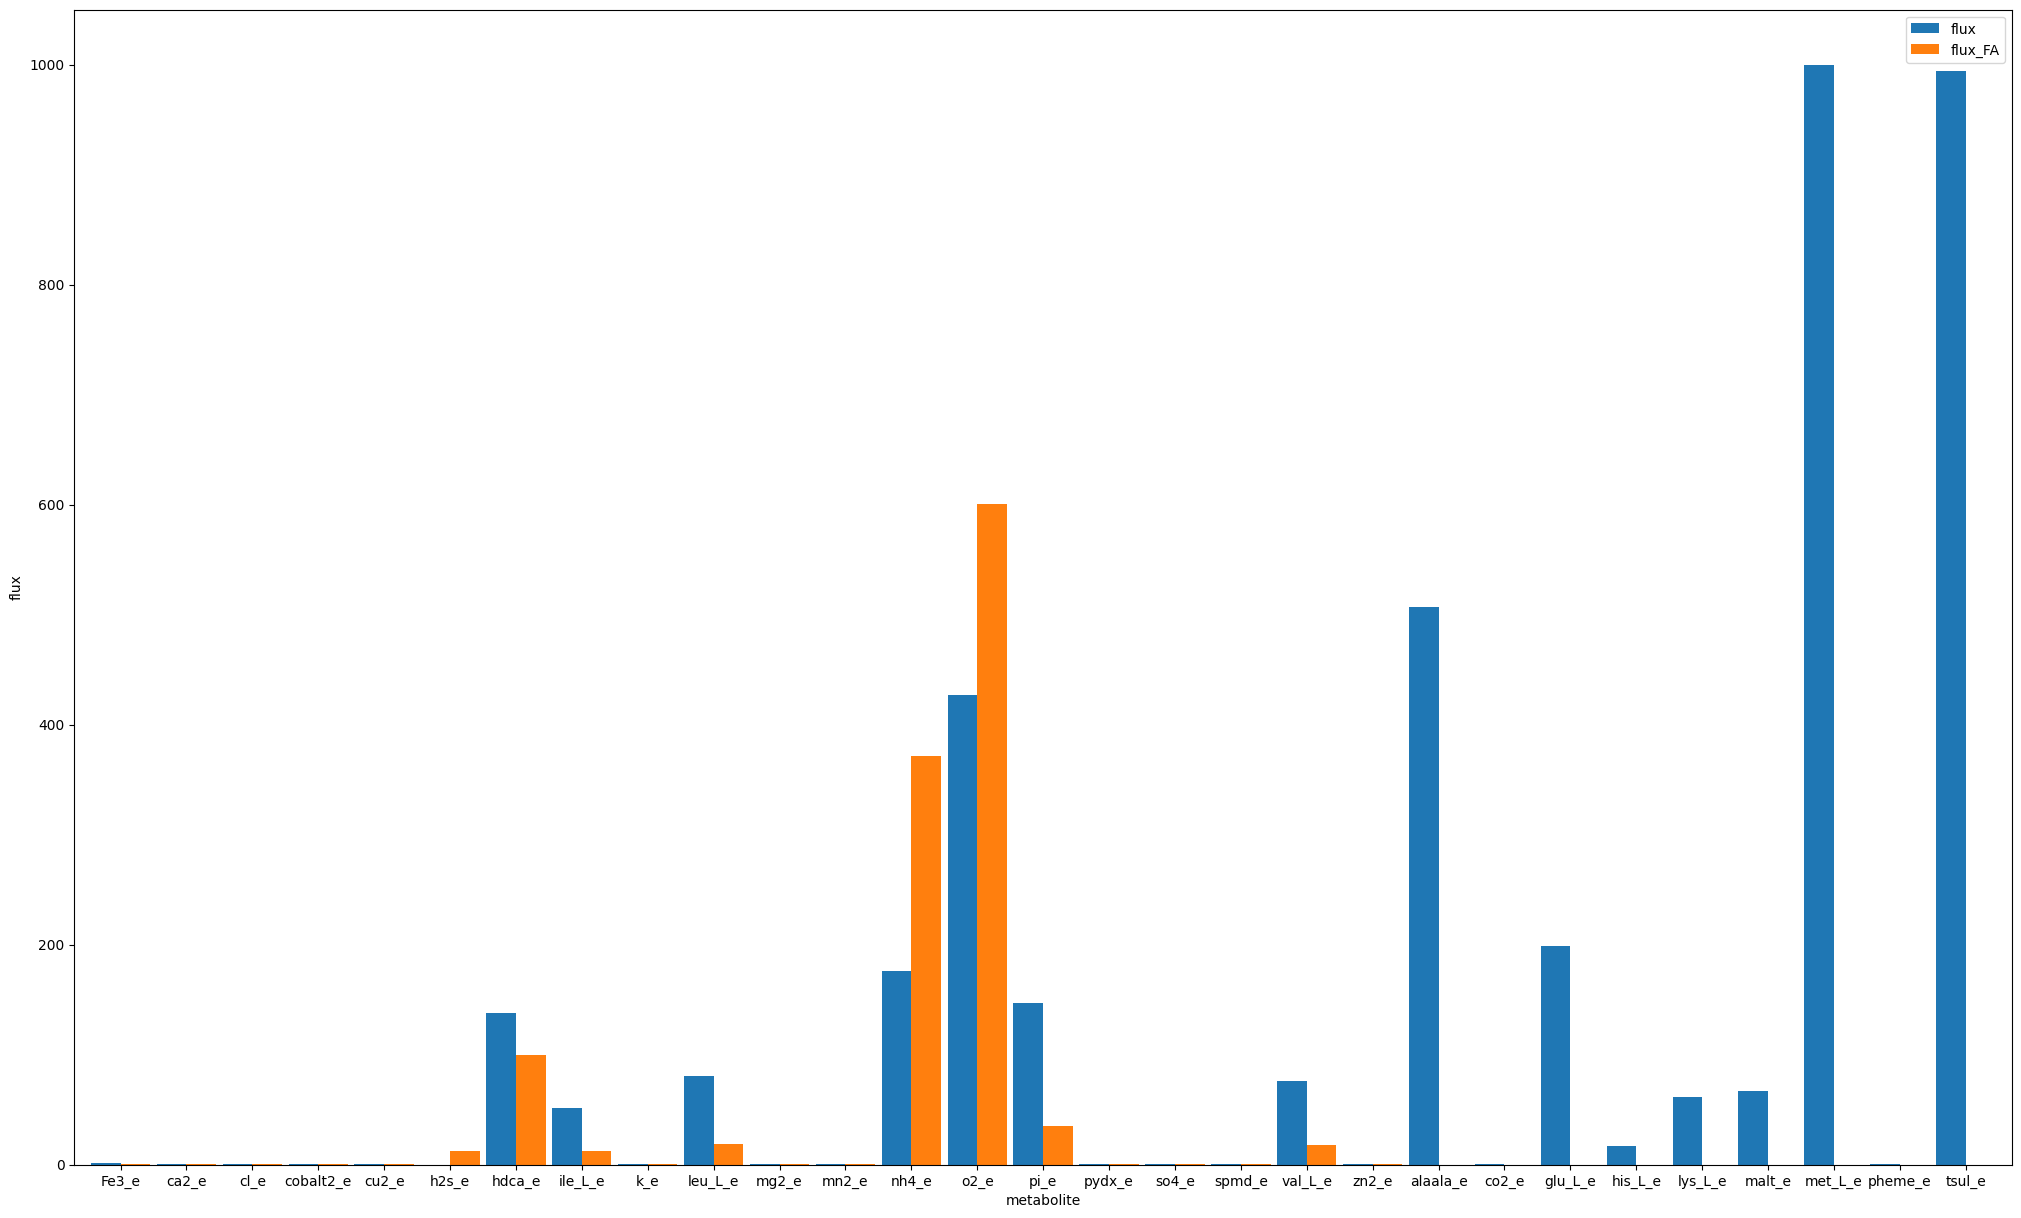

In [ ]:
ax2 = df2.plot.bar(x="metabolite", y=["flux","flux_FA"], rot=0, figsize=(25, 15), width = 0.9, ylabel = "flux")

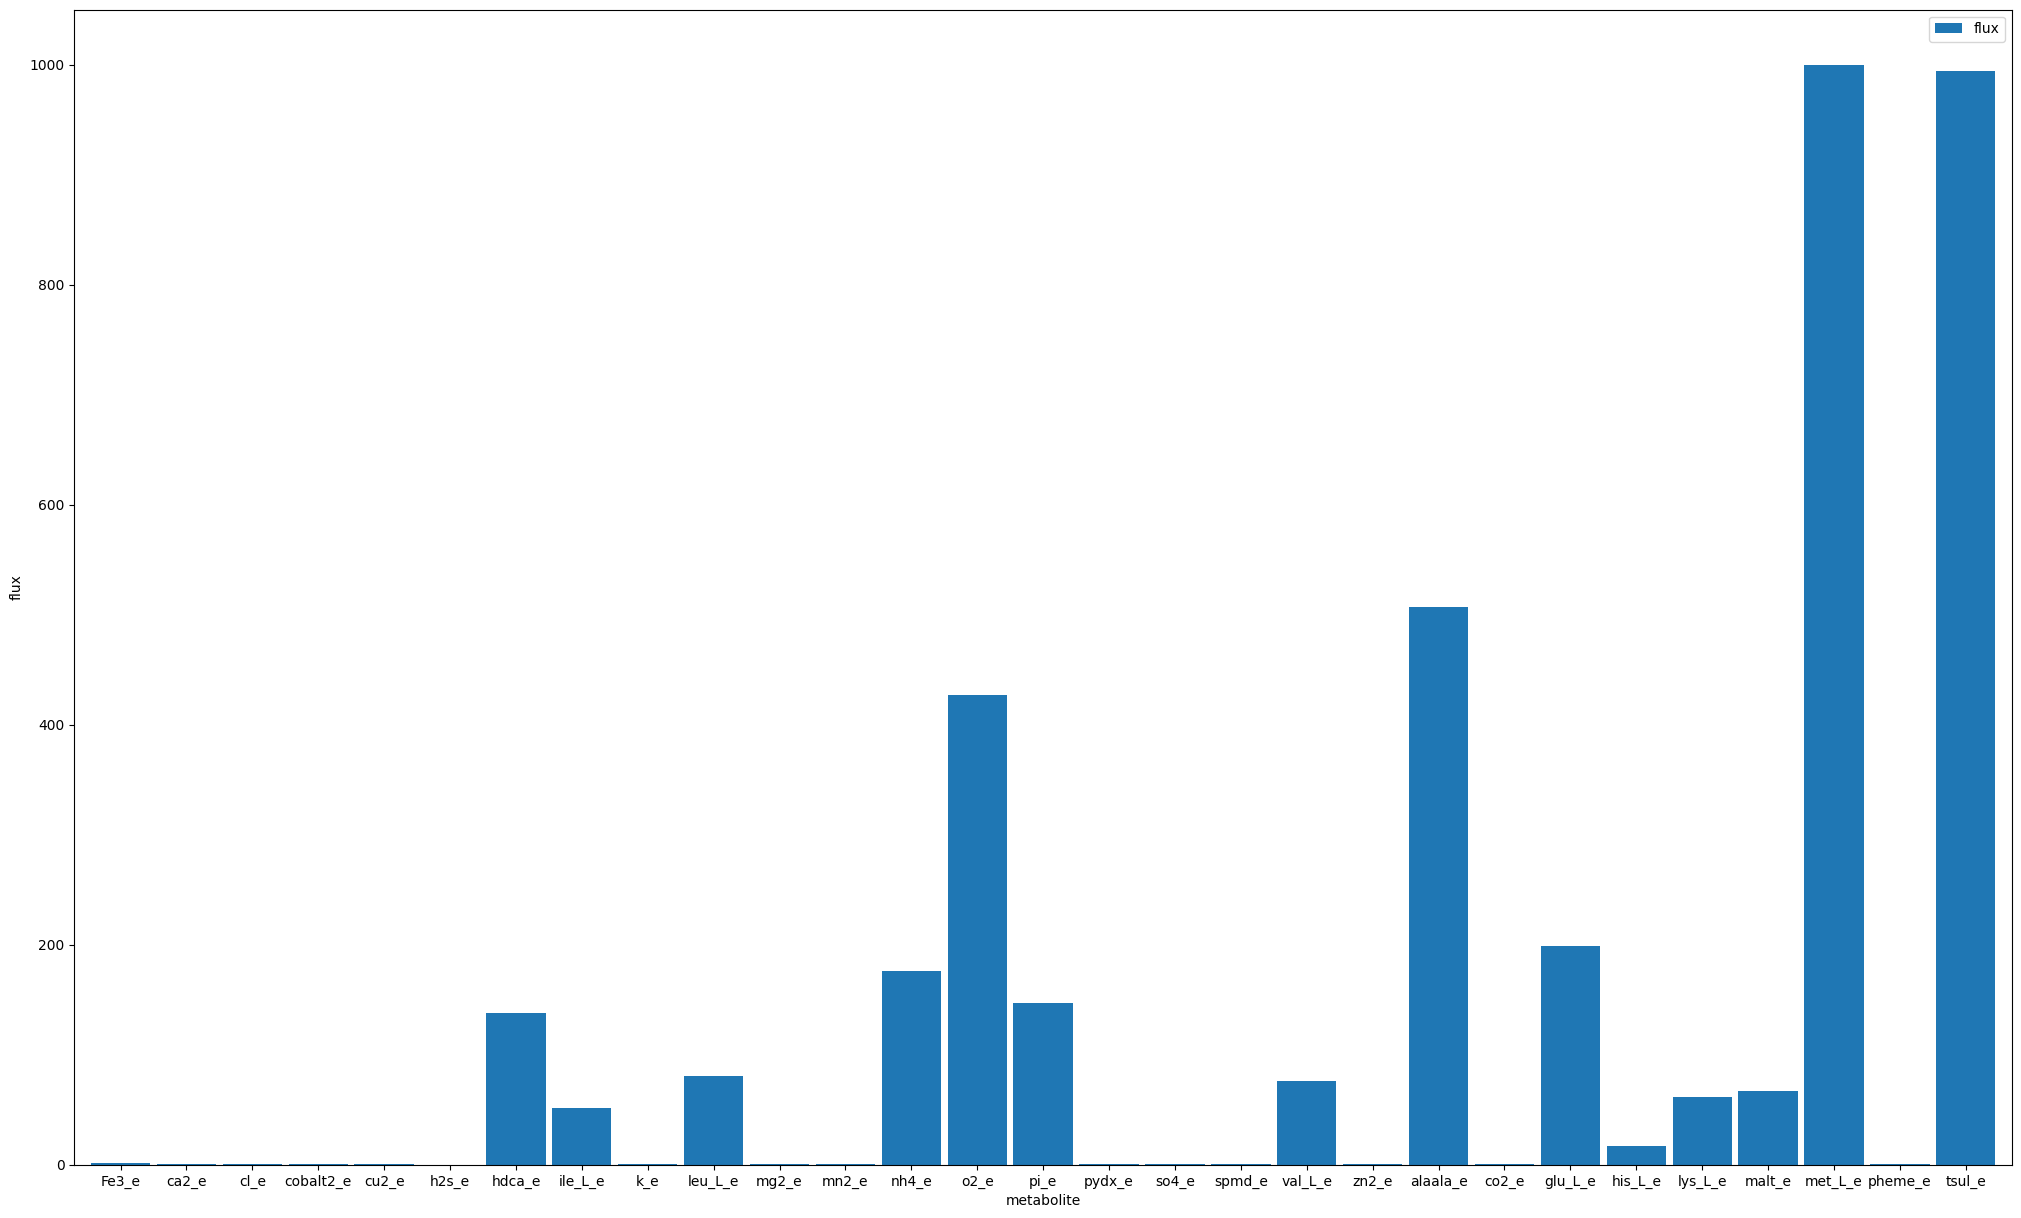

In [284]:
ax2 = df2.plot.bar(x="metabolite", y=["flux"], rot=0, figsize=(25, 15), width = 0.9, ylabel = "flux")

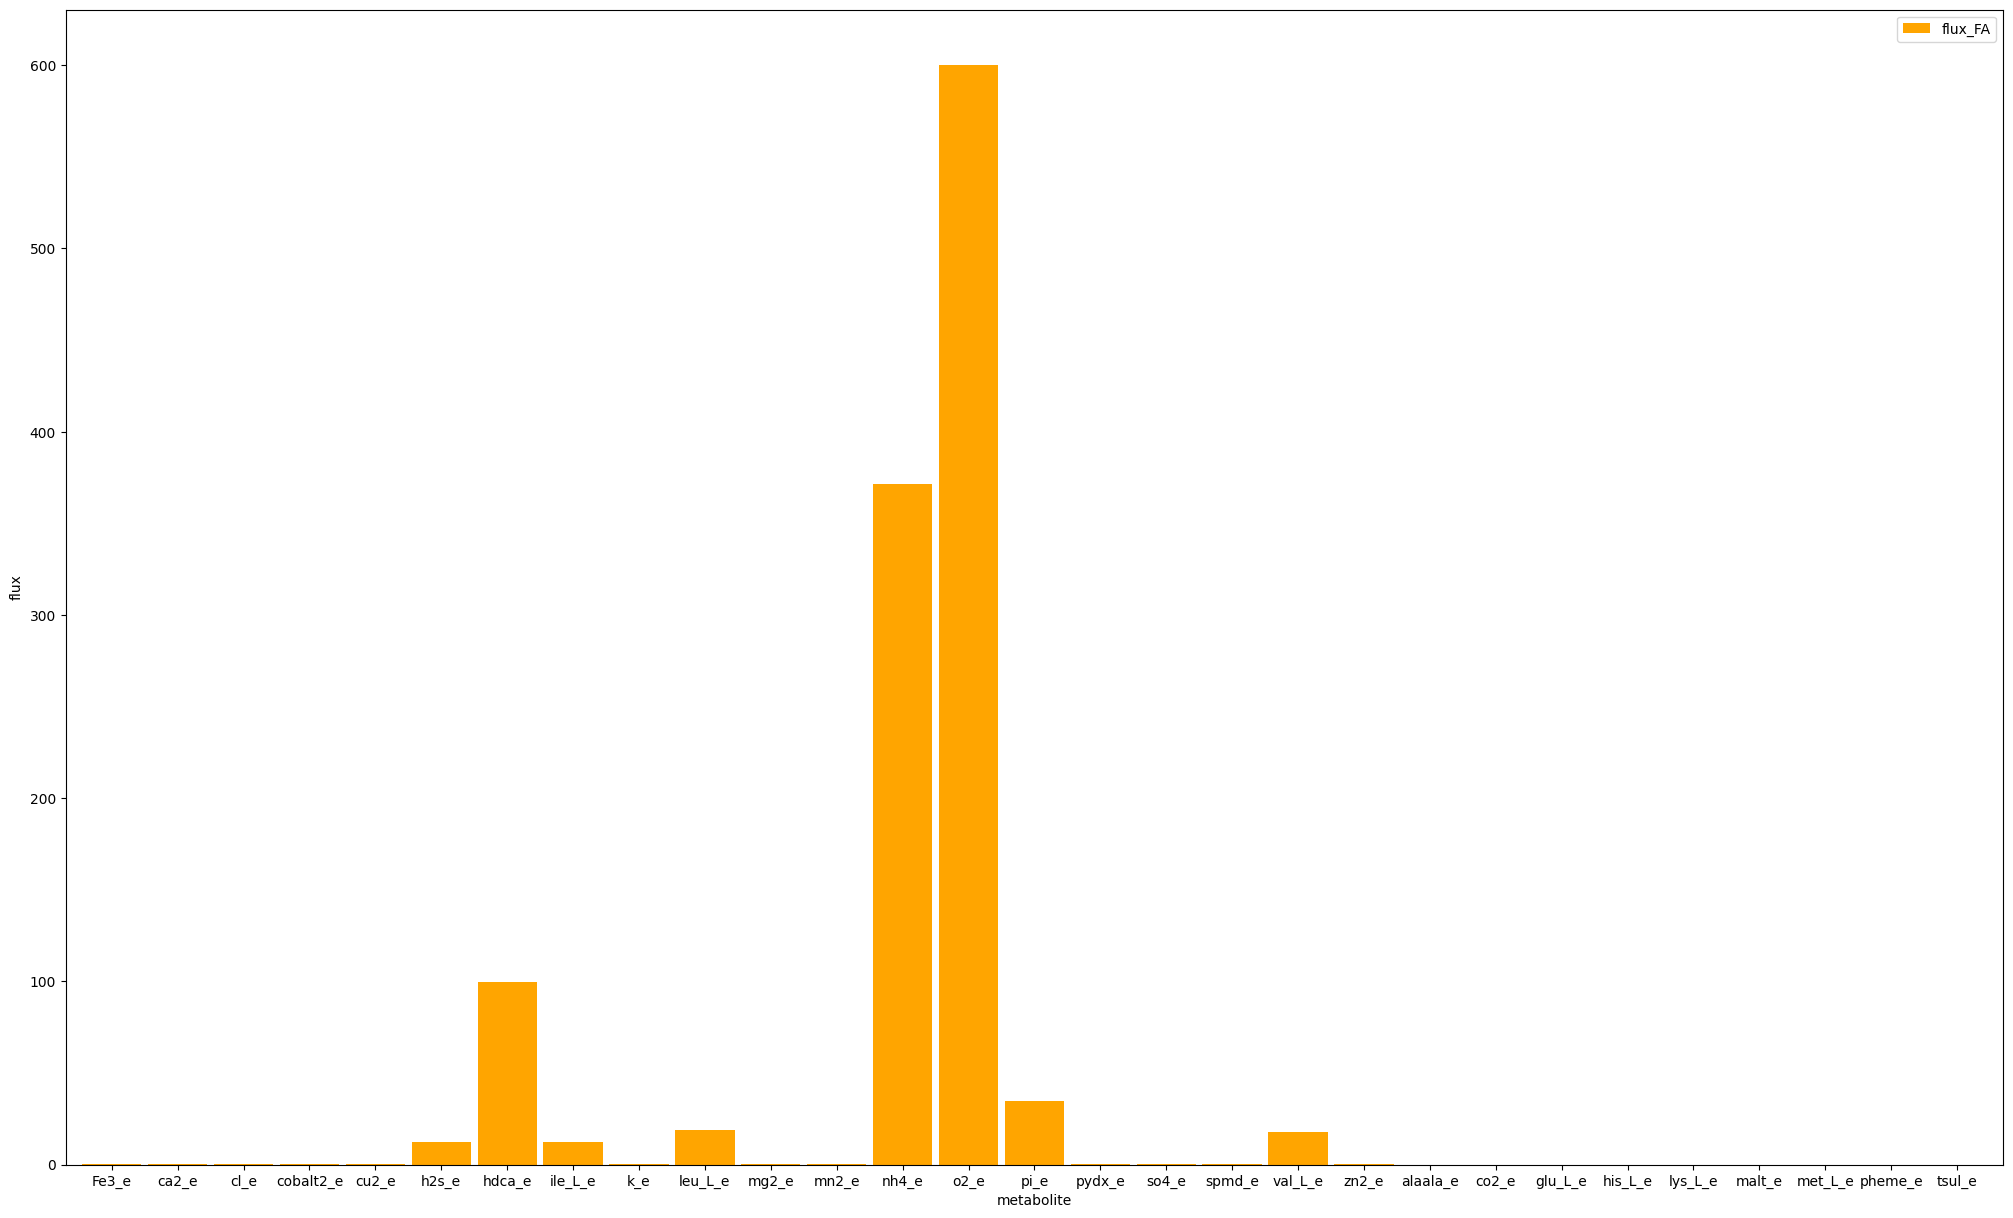

In [286]:
ax2 = df2.plot.bar(x="metabolite", y=["flux_FA"], rot=0, figsize=(25, 15), width = 0.9, ylabel = "flux", color="Orange")